# ML Models (Methods)

Three machine learning approaches on the 1M student burnout dataset:
- **Decision Tree** — simple interpretable classifier
- **Random Forest** — ensemble method with feature importances
- **K-Means Clustering** — unsupervised grouping of students by lifestyle

(Extra) Finally, personal risk prediction using Apple Health data.

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.options.display.float_format = '{:.4f}'.format

## Loading Data

Sample 100k rows from the 1M burnout dataset for manageable training time.
Apple Health data is used later for personal prediction.

In [116]:
# loading the data.
burnout = pd.read_csv('burnout_processed.csv')
health  = pd.read_csv('health_processed.csv', parse_dates=['date'])

# sampling the data.
burnout_sample = burnout.sample(n=100_000, random_state=42).reset_index(drop=True)
print('Burnout full: ', burnout.shape)
print('Sampled: ', burnout_sample.shape)
print('Health: ', health.shape)
print('\nRisk level distribution: ')
print(burnout_sample['risk_level'].value_counts())

Burnout full:  (1000000, 22)
Sampled:  (100000, 22)
Health:  (577, 10)

Risk level distribution: 
risk_level
Low       76654
Medium    21851
High       1495
Name: count, dtype: int64


In [117]:
# selecting the features.
FEATURES = [
    'study_hours_per_day',
    'exam_pressure',
    'stress_level',
    'sleep_hours',
    'physical_activity',
    'social_support',
    'screen_time',
    'financial_stress',
    'family_expectation',
]

# set a target group
TARGET = 'risk_level_encoded'

X = burnout_sample[FEATURES]
y = burnout_sample[TARGET]

# first split off the test set (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# then split train/validation from the remaining 85% → 70% / 15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)')

Train: 70040 (70%)
Validation: 14960 (15%)
Test: 15000 (15%)


## Decision Tree

Max-depth=3 because it makes it overfit if bigger.
A simple tree-based model.

In [118]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# evaluate on validation and test sets
acc_dt_val = accuracy_score(y_val,  dt.predict(X_val))
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

print(f'Decision Tree — Validation Accuracy: {acc_dt_val:.4f}')
print(f'Decision Tree — Test Accuracy: {acc_dt:.4f}\n')
print(classification_report(y_test, y_pred_dt, target_names=['Low', 'Medium', 'High']))

Decision Tree — Validation Accuracy: 0.8416
Decision Tree — Test Accuracy: 0.8401

              precision    recall  f1-score   support

         Low       0.89      0.92      0.91     11498
      Medium       0.64      0.61      0.62      3278
        High       0.00      0.00      0.00       224

    accuracy                           0.84     15000
   macro avg       0.51      0.51      0.51     15000
weighted avg       0.82      0.84      0.83     15000



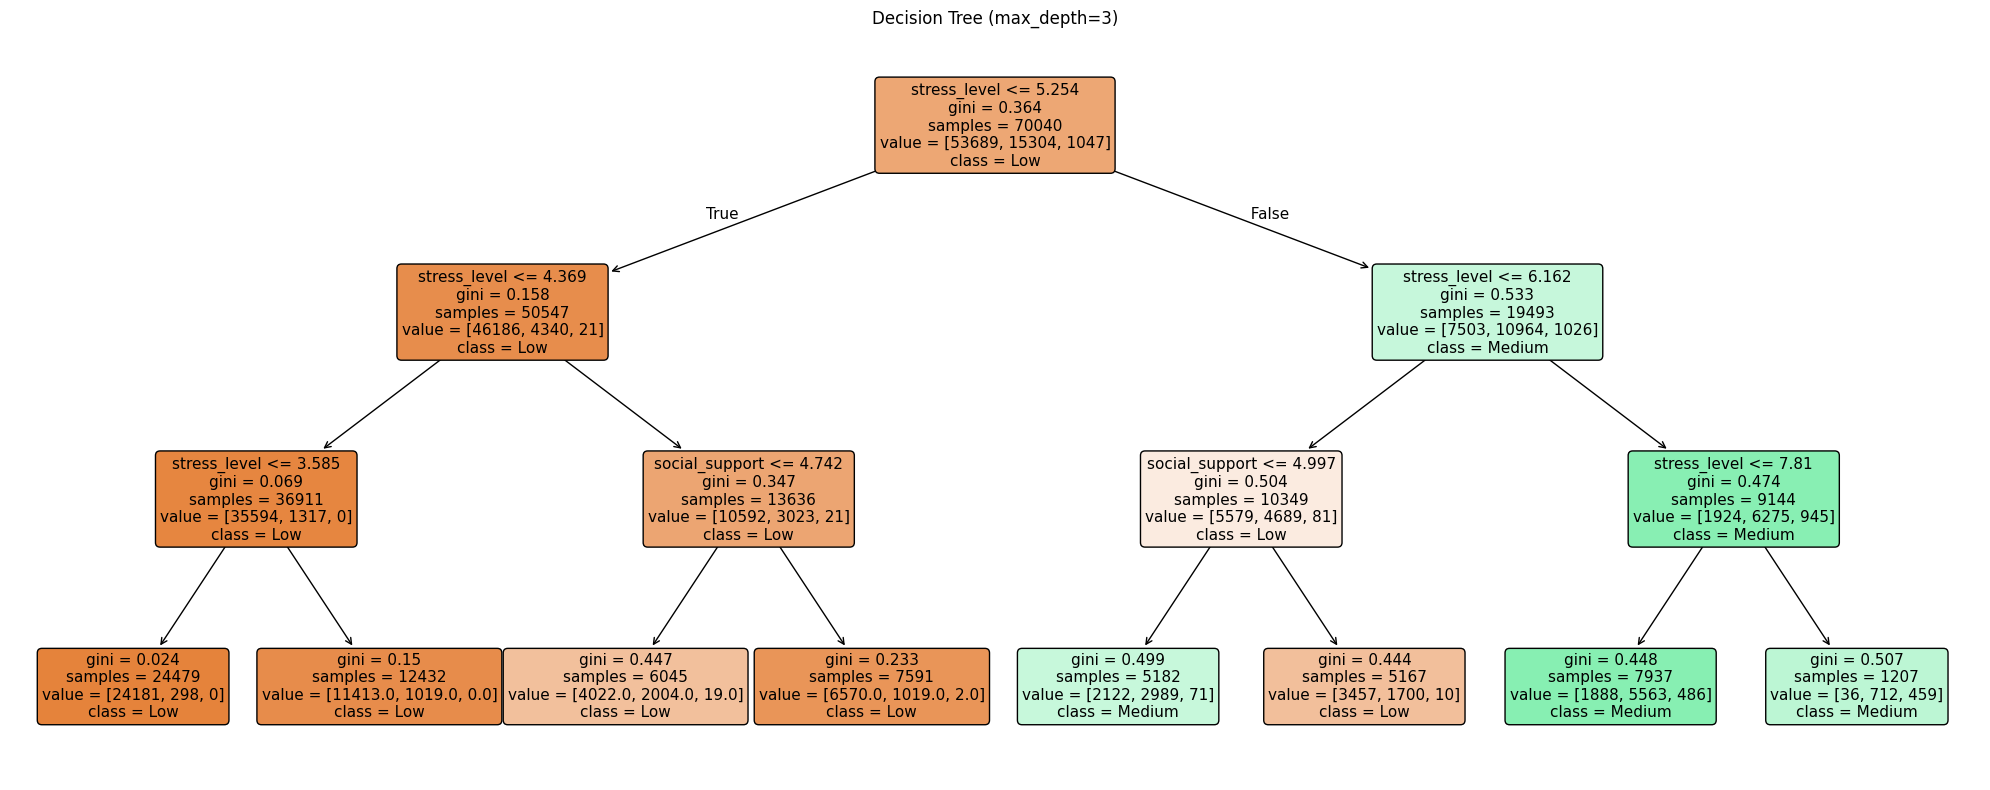

In [119]:
# create a decision tree plot.
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=FEATURES, class_names=['Low', 'Medium', 'High'],
          filled=True, rounded=True, fontsize=11, ax=ax)
ax.set_title('Decision Tree (max_depth=3)')
plt.tight_layout()
plt.savefig('plots/ml_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## Random Forest

An analysis of 100 decision trees. More robust than a single tree and gives feature importances.

In [120]:
# creating the forest (random)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# evaluate on validation and test sets
acc_rf_val = accuracy_score(y_val,  rf.predict(X_val))
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f'Random Forest — Validation Accuracy: {acc_rf_val:.4f}')
print(f'Random Forest — Test Accuracy: {acc_rf:.4f}\n')
print(classification_report(y_test, y_pred_rf, target_names=['Low', 'Medium', 'High']))

Random Forest — Validation Accuracy: 0.8555
Random Forest — Test Accuracy: 0.8553

              precision    recall  f1-score   support

         Low       0.90      0.94      0.92     11498
      Medium       0.69      0.61      0.65      3278
        High       0.66      0.22      0.33       224

    accuracy                           0.86     15000
   macro avg       0.75      0.59      0.63     15000
weighted avg       0.85      0.86      0.85     15000



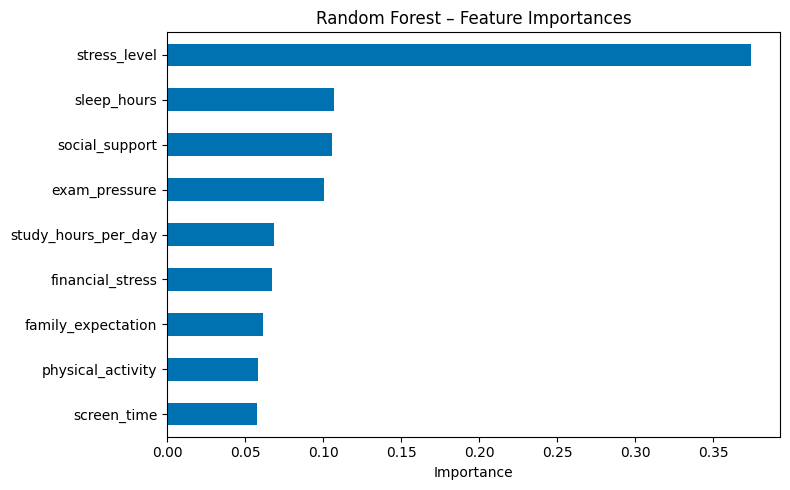

In [121]:
# creating a graph of most important features.
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#0072B2')
ax.set_xlabel('Importance')
ax.set_title('Random Forest – Feature Importances')
plt.tight_layout()
plt.savefig('plots/ml_feature_importance.png', dpi=150)
plt.show()

## K-Means Clustering

Group students into natural clusters based on lifestyle features, without using "risk_level".
Then check how well these clusters align with the actual risk labels.

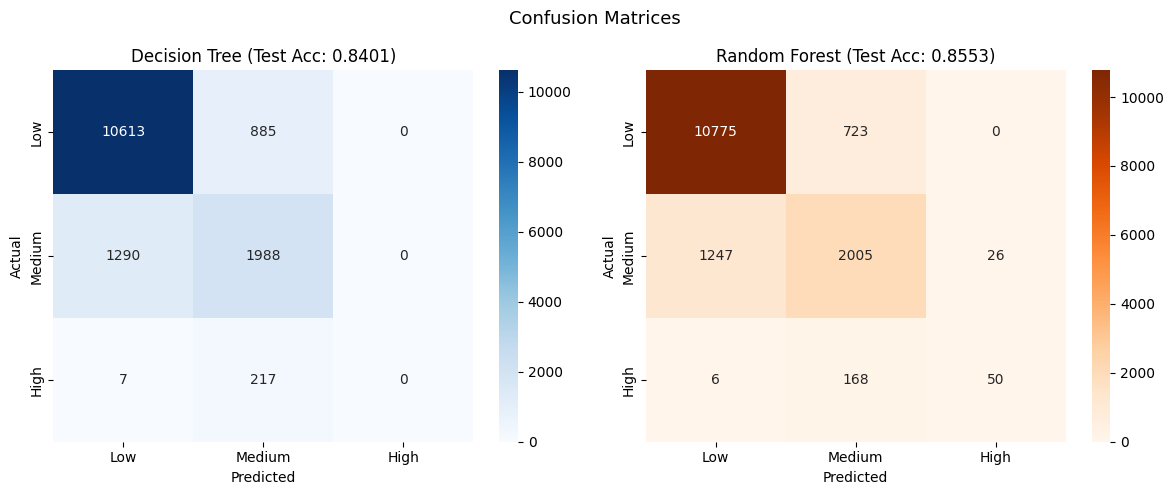

In [122]:
# creating confusion matrixes out of 
# the decision trees and random forest (with the given accuracies.)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Decision Tree (Test Acc: {acc_dt:.4f})')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'], ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title(f'Random Forest (Test Acc: {acc_rf:.4f})')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('plots/ml_confusion_matrix.png', dpi=150)
plt.show()

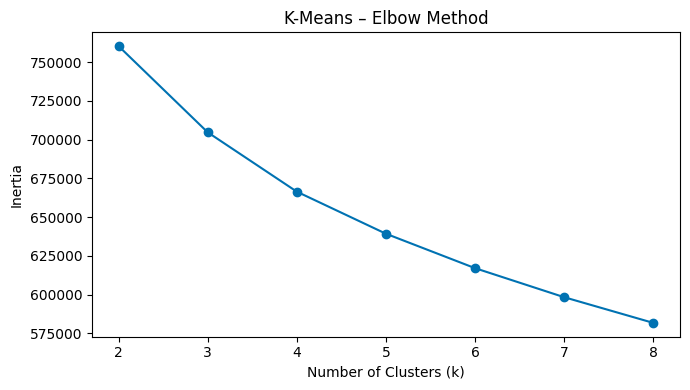

In [123]:
# creating also the elbow of kmeans.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o', color='#0072B2')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('K-Means – Elbow Method')
plt.tight_layout()
plt.savefig('plots/ml_kmeans_elbow.png', dpi=150)
plt.show()

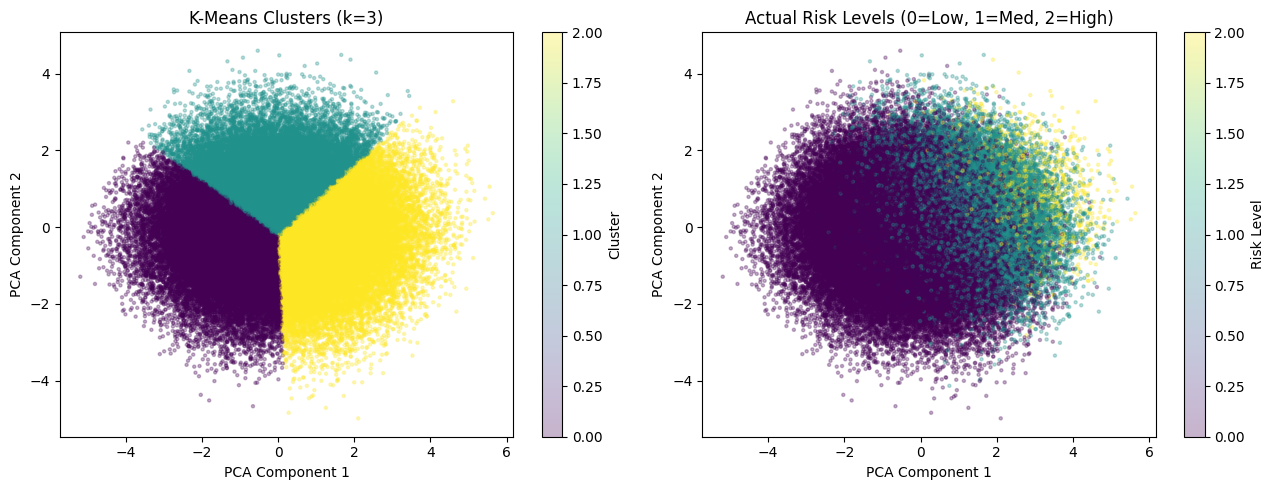

Cluster vs Risk Level distribution:
risk_level      0      1     2
cluster                       
0           33499    646     0
1           21975   7882   346
2           21180  13323  1149


In [124]:
# fit k=3 (matches Low/Medium/High)
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km3.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=clusters, cmap='viridis', alpha=0.3, s=5)
axes[0].set_title('K-Means Clusters (k=3)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                           c=y, cmap='viridis', alpha=0.3, s=5)
axes[1].set_title('Actual Risk Levels (0=Low, 1=Med, 2=High)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(scatter2, ax=axes[1], label='Risk Level')

plt.tight_layout()
plt.savefig('plots/ml_kmeans_clusters.png', dpi=150)
plt.show()

cluster_df = pd.DataFrame({'cluster': clusters, 'risk_level': y.values})
print('Cluster vs Risk Level distribution:')
print(cluster_df.groupby('cluster')['risk_level'].value_counts().unstack(fill_value=0))

## Personal Risk Prediction (EXTRA) (Using some estimated data)

Using my Apple Health data to build a personal feature vector and predict where I fall
on the risk spectrum, both during exam periods and normal periods. (Because Apple Watch does not give all the required data as I don't tend to wear my watch every day)

Feature mapping:
- `physical_activity` ← `physical_activity_normalized` from Apple Health (both are 0–7 scale)
- Other features are personal estimates on the same scale as the dataset

In [125]:
exam_pa     = health[health['is_exam_period'] == 1]['physical_activity_normalized'].mean()
non_exam_pa = health[health['is_exam_period'] == 0]['physical_activity_normalized'].mean()

print(f'My avg physical_activity (exam): {exam_pa:.2f} / 7')
print(f'My avg physical_activity (non-exam): {non_exam_pa:.2f} / 7')

personal_exam = {
    'study_hours_per_day': 7.0,
    'exam_pressure':       8.0,
    'stress_level':        6.5,
    'sleep_hours':         6.0,
    'physical_activity':   exam_pa,
    'social_support':      4.0,
    'screen_time':         5.0,
    'financial_stress':    4.0,
    'family_expectation':  6.0,
}

personal_non_exam = {
    'study_hours_per_day': 5.0,
    'exam_pressure':       4.0,
    'stress_level':        4.0,
    'sleep_hours':         7.0,
    'physical_activity':   non_exam_pa,
    'social_support':      6.0,
    'screen_time':         5.0,
    'financial_stress':    4.0,
    'family_expectation':  6.0,
}

df_personal = pd.DataFrame([personal_exam, personal_non_exam],
                            index=['Exam Period', 'Non-Exam Period'])

My avg physical_activity (exam): 4.19 / 7
My avg physical_activity (non-exam): 3.98 / 7


In [126]:
label_map = {0: 'Low', 1: 'Medium', 2: 'High'}

pred_dt = dt.predict(df_personal[FEATURES])
prob_dt = dt.predict_proba(df_personal[FEATURES])

pred_rf = rf.predict(df_personal[FEATURES])
prob_rf = rf.predict_proba(df_personal[FEATURES])

print('=== Decision Tree ===')
for i, period in enumerate(['Exam Period', 'Non-Exam Period']):
    print(f'  {period}: {label_map[pred_dt[i]]}  '
          f'(Low={prob_dt[i][0]:.2f}, Med={prob_dt[i][1]:.2f}, High={prob_dt[i][2]:.2f})')

print('\n=== Random Forest ===')
for i, period in enumerate(['Exam Period', 'Non-Exam Period']):
    print(f'  {period}: {label_map[pred_rf[i]]}  '
          f'(Low={prob_rf[i][0]:.2f}, Med={prob_rf[i][1]:.2f}, High={prob_rf[i][2]:.2f})')

=== Decision Tree ===
  Exam Period: Medium  (Low=0.24, Med=0.70, High=0.06)
  Non-Exam Period: Low  (Low=0.92, Med=0.08, High=0.00)

=== Random Forest ===
  Exam Period: Medium  (Low=0.10, Med=0.85, High=0.05)
  Non-Exam Period: Low  (Low=0.99, Med=0.01, High=0.00)


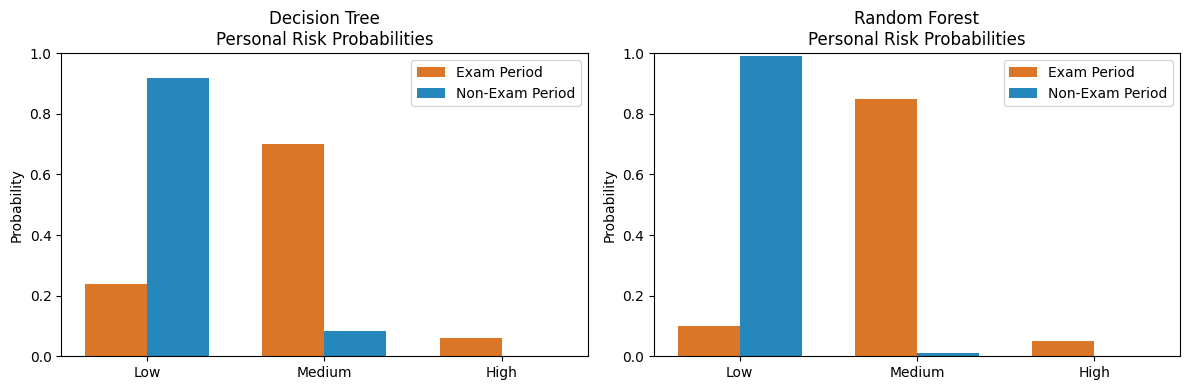

In [127]:
# my personal data.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
categories = ['Low', 'Medium', 'High']

for ax, prob, model_name in zip(
    axes,
    [prob_dt, prob_rf],
    ['Decision Tree', 'Random Forest']
):
    x = range(len(categories))
    width = 0.35
    ax.bar([i - width/2 for i in x], prob[0], width,
           label='Exam Period', color='#D55E00', alpha=0.85)
    ax.bar([i + width/2 for i in x], prob[1], width,
           label='Non-Exam Period', color='#0072B2', alpha=0.85)
    ax.set_xticks(list(x))
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability')
    ax.set_title(f'{model_name}\nPersonal Risk Probabilities')
    ax.legend()

plt.tight_layout()
plt.savefig('plots/ml_personal_prediction.png', dpi=150)
plt.show()